# Visualize mSWE-GNN results — Ahr river (additionalsrc_velocity, 100 m SFINCS run)

Ground truth: `ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon`  
Grid: 100 m resolution, hourly time steps.

**Workflow**
1. **Step 1a** — Create a 100 m mesh template from `gis/region.geojson` + `gis/dep.tif` + `sfincs_map.nc`.
2. **Step 1b** — Convert the SFINCS run to a `.pkl` dataset using the 100 m template.
3. Load dataset + model, run inference, visualise.

In [24]:
import sys
print(sys.executable)


c:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\python.exe


In [25]:
import sys, os

# Set PROJ database path before any geopandas/pyproj import so CRS lookups work.
_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Paths

In [ ]:
SFINCS_DIR    = os.path.join(REPO_ROOT, 'database', 'raw_datasets_ahr', 'Simulations',
                             'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon')
SFINCS_MAP    = os.path.join(SFINCS_DIR, 'sfincs_map.nc')
SFINCS_SRC    = os.path.join(SFINCS_DIR, 'sfincs.src')
SFINCS_DIS    = os.path.join(SFINCS_DIR, 'sfincs.dis')
GIS_DIR       = os.path.join(SFINCS_DIR, 'gis')
SHAPEFILE     = os.path.join(GIS_DIR, 'region.geojson')
DEM_TIF       = os.path.join(GIS_DIR, 'dep.tif')

TEMPLATE_100M = 'database/datasets/train/template_100m.pkl'
DATASET_NAME  = 'ahr_river_v03_marg_additionalsrc_velocity_100m_cutpolygon'
OUT_ROOT      = 'database/datasets'

FORCE_REBUILD = True   # rebuild PKL from new simulation

for p in [SFINCS_MAP, SFINCS_SRC, SFINCS_DIS]:
    print('OK  ' if os.path.exists(p) else 'MISSING', p)

In [ ]:
import xarray as xr
import numpy as np

# Check both the repo copy and the original SFINCS folder
ORIGINAL_SFINCS_MAP = r'C:\Users\marrocol\OneDrive - Stichting Deltares\Documents\SFINCS\ahr_river_v03_Marg_additionalsrc_100m_cutpolygon\sfincs_map.nc'

for label, path in [('REPO COPY', SFINCS_MAP), ('ORIGINAL', ORIGINAL_SFINCS_MAP)]:
    if not os.path.exists(path):
        print(f'{label}: MISSING {path}')
        continue
    ds = xr.open_dataset(path, decode_times=False)
    zs = ds['zs'].values  # [T, n, m]
    msk = ds['msk'].values if 'msk' in ds else None
    # Count cells that ever have zs > 0.05 m (flooded)
    flooded = (zs > 0.05).any(axis=0)
    n_flooded = int(flooded.sum())
    zs_peak = float(np.nanmax(zs))
    print(f'{label}: shape={zs.shape}  peak_zs={zs_peak:.2f} m  ever-flooded cells={n_flooded}')
    ds.close()

## Step 1a — Create 100 m mesh template
Uses `region.geojson` as the domain boundary, `dep.tif` as the DEM, and `sfincs_map.nc` as the finest mesh level.  
Coarser levels are built with gmsh — install first if needed: `pip install gmsh pygmsh`

In [27]:
if FORCE_REBUILD and os.path.exists(TEMPLATE_100M):
    os.remove(TEMPLATE_100M)
    print(f'Deleted stale template: {TEMPLATE_100M}')

if os.path.exists(TEMPLATE_100M):
    print(f'Template already exists: {TEMPLATE_100M}\nSkipping.')
else:
    from database.create_mesh_template_marg import create_mesh_template_pkl

    # Domain diagonal ≈ 42 km  →  3 coarser gmsh levels + SFINCS 100 m finest level
    create_mesh_template_pkl(
        shapefile_path    = SHAPEFILE,
        dem_tif_path      = DEM_TIF,
        output_pkl_path   = TEMPLATE_100M,
        with_multiscale   = True,
        number_of_multiscales = 4,
        mesh_resolutions  = [2000, 1000, 500],  # coarse → fine (SFINCS is finest)
        sfincs_map_nc     = SFINCS_MAP,
    )
    print(f'Template saved: {TEMPLATE_100M}')

Deleted stale template: database/datasets/train/template_100m.pkl

=== Creating Mesh Template ===
Shapefile: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_100m_cutpolygon\gis\region.geojson
DEM: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_100m_cutpolygon\gis\dep.tif
Output: database/datasets/train/template_100m.pkl
Multiscale: True

1. Converting shapefile to polygon...
   Polygon area: 249940000.00 m²
   Boundary length: 132800.00 m
   Polygon bounds: (344900.0, 5581800.0, 378100.0, 5607600.0)
   DEM bounds: (344900.0, 5581800.0, 378100.0, 5607600.0)

2. Creating polygon file (.gpkg)...

3. Processing DEM...


c:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


  Saved DEM XYZ: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\datasets\train\temp_dem.xyz
   DEM points: 24994
   Elevation range: 51.03 to 554.46 m

4. Creating mesh from polygon...
   Mesh resolutions (m): [2000, 1000, 500]
   Loading SFINCS mesh from: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\database\raw_datasets_ahr\Simulations\ahr_river_v03_Marg_additionalsrc_100m_cutpolygon\sfincs_map.nc
   SFINCS mesh faces: 24994
   Finest mesh nodes: 25658
   Finest mesh faces: 24994
   Finest mesh edges: 50652

5. Interpolating DEM to mesh...
   Interpolated DEM range (finest): 51.03 to 554.46 m

6. Adding ghost cells for boundary conditions...
   Multiscale meshes: 4
   Boundary nodes (ghost cells): 90

7. Creating dummy time series...
   Shapes: WD=torch.Size([30166, 10]), VX=torch.Size([30166, 10]), VY=torch.Size([30166, 10])

8. Creating boundary condition structure...
   BC no

## Step 1b — Convert SFINCS 100 m run → .pkl dataset
Interpolates the SFINCS water depth onto the 100 m template mesh and saves train/test pkls.

In [ ]:
import copy, pickle
import xarray as xr
from database.convert_sfincs_to_pkl_marg import (
    load_single_data_object, get_target_points,
    parse_src_file, parse_dis_file, build_output_data,
)

if FORCE_REBUILD:
    for split in ('train', 'test'):
        p = os.path.join(OUT_ROOT, split, f'{DATASET_NAME}.pkl')
        if os.path.exists(p):
            os.remove(p)
            print(f'Deleted stale dataset: {p}')

test_pkl = os.path.join(OUT_ROOT, 'test', f'{DATASET_NAME}.pkl')
if os.path.exists(test_pkl):
    print(f'Dataset already exists: {test_pkl}\nSkipping.')
else:
    print('Loading 100 m template mesh...')
    template_data = load_single_data_object(TEMPLATE_100M)
    target_points = get_target_points(template_data)
    print(f'  Target mesh faces: {target_points.shape[0]}')

    print('Opening SFINCS map...')
    ds = xr.open_dataset(SFINCS_MAP, decode_times=False)

    msk = ds['msk'].values                 # (n_rows, n_cols)
    x   = ds.coords['x'].values
    y   = ds.coords['y'].values
    if x.ndim == 1:
        x, y = np.meshgrid(x, y, indexing='xy')
    active        = msk > 0
    source_points = np.column_stack([x[active], y[active]])
    print(f'  Active source cells: {source_points.shape[0]}  (total grid: {msk.size})')

    zs = ds['zs'].values          # [T, n_rows, n_cols]
    zb = ds['zb'].values          # [n_rows, n_cols]
    time_var    = ds.coords.get('time', ds.coords.get('t', None))
    map_times_s = time_var.values.astype(np.float64) if time_var is not None \
                  else np.arange(zs.shape[0]) * 3600.0
    print(f'  Time steps: {len(map_times_s)}  ({map_times_s[0]:.0f} – {map_times_s[-1]:.0f} s)')

    print('Computing WD on active cells...')
    zs_active = zs[:, active]              # [T, n_active], NaN where cell is dry
    zb_active = zb[active]                 # [n_active]
    # Treat NaN zs as bed elevation (dry cell, WD=0) so every active cell
    # is a valid source point for griddata — prevents nearest-neighbour
    # filling from spreading flood water into dry areas.
    zs_filled = np.where(np.isnan(zs_active), zb_active[None, :], zs_active)
    WD_active = np.maximum(zs_filled - zb_active[None, :], 0.0).astype(np.float32)
    print(f'  Peak WD: {WD_active.max():.3f} m')
    print(f'  Ever-flooded cells (WD>0.05 m): {(WD_active > 0.05).any(axis=0).sum()}')

    print('Interpolating WD to mesh...')
    from scipy.interpolate import griddata
    time_steps  = WD_active.shape[0]
    num_targets = target_points.shape[0]
    WD_out      = np.zeros((num_targets, time_steps), dtype=np.float32)
    for t in range(time_steps):
        vals = WD_active[t]               # no NaN — all active cells are valid
        interp = griddata(source_points, vals, target_points, method='linear')
        nan_mask = ~np.isfinite(interp)   # only faces outside active domain
        if nan_mask.any():
            interp[nan_mask] = 0.0        # outside active domain → dry
        WD_out[:, t] = interp
    WD = WD_out
    VX = np.zeros_like(WD, dtype=np.float32)
    VY = np.zeros_like(WD, dtype=np.float32)

    print('Reading source / discharge files...')
    src_xy                 = parse_src_file(SFINCS_SRC)
    dis_times_s, discharge = parse_dis_file(SFINCS_DIS)
    print(f'  {len(src_xy)} sources,  discharge shape: {discharge.shape}')

    data_out = build_output_data(
        template_data, WD=WD, VX=VX, VY=VY,
        map_times_s=map_times_s, src_xy=src_xy,
        dis_times_s=dis_times_s, discharge=discharge,
    )

    for split in ('train', 'test'):
        out_dir  = os.path.join(OUT_ROOT, split)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f'{DATASET_NAME}.pkl')
        with open(out_path, 'wb') as f:
            pickle.dump([copy.deepcopy(data_out)], f)
        print(f'  Saved: {out_path}')

    print(f'Done.  WD shape: {tuple(data_out.WD.shape)}')

## Step 2 — Load config and dataset

In [29]:
cfg = read_config('config_finetune.yaml')

# Override dataset name to point at the 100 m run
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')   # change to 'cuda' if GPU is available
print('Test dataset:', config.dataset_parameters['test_dataset_name'])

Test dataset: ahr_river_v03_marg_additionalsrc_100m_cutpolygon


In [30]:
_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)
print('Test size:', len(test_dataset))
print('Mesh type:', type(test_dataset[0].mesh).__name__)
print('WD shape: ', test_dataset[0].WD.shape)
print('Scalers:  ', scalers)

The validation dataset you are using is the training one. Careful!
Test size: 1
Mesh type: MultiscaleMesh
WD shape:  torch.Size([30079, 121])
Scalers:   {'DEM_scaler': StandardScaler(), 'slope_scaler': None, 'area_scaler': [StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()], 'edge_length_scaler': [StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()], 'edge_slope_scaler': None, 'WD_scaler': None, 'V_scaler': None}


## Step 3 — Inspect mesh levels

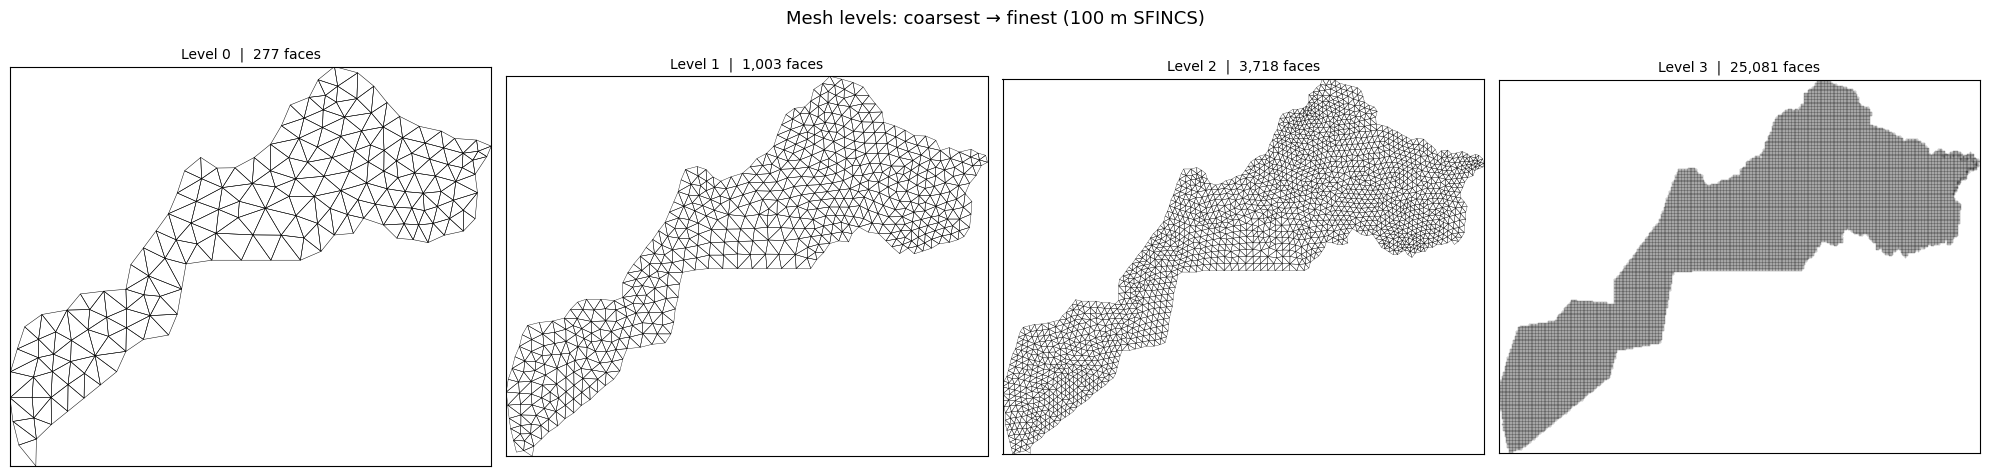

In [31]:
from database.graph_creation import plot_faces

meshes = test_dataset[0].mesh.meshes
n = len(meshes)

fig, axs = plt.subplots(1, n, figsize=(n * 5, 5))
fig.suptitle('Mesh levels: coarsest → finest (100 m SFINCS)', fontsize=13)

for i, m in enumerate(meshes):
    ax = axs[i] if n > 1 else axs
    lw = max(0.05, 0.35 - i * 0.07)
    plot_faces(m, ax=ax, facecolor='none', edgecolor='black', linewidth=lw)
    ax.set_aspect('equal')
    ax.set_title(f'Level {i}  |  {m.face_x.shape[0]:,} faces', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 4 — Load model

In [32]:
temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)
print(f'num_node_features: {num_node_features},  num_edge_features: {num_edge_features}')

model_parameters = dict(config.models)
model_type = model_parameters.pop('model_type')

if model_type == 'MSGNN':
    model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

model = get_model(model_type)(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    previous_t=temporal_test_dataset_parameters['previous_t'],
    device=device,
    **model_parameters
).to(device)

plmodule_kwargs = {
    'model': model,
    'lr_info': config['lr_info'],
    'trainer_options': config.trainer_options,
    'temporal_test_dataset_parameters': temporal_test_dataset_parameters
}

plmodule = LightningTrainer.load_from_checkpoint(
    config.saved_model, map_location=device, **plmodule_kwargs
)
model = plmodule.model.to(device)
model.eval()
print('Model loaded from:', config.saved_model)

num_node_features: 8,  num_edge_features: 1
Model loaded from: results/finetuned_dk15.h5


## Step 5 — Run inference

In [33]:
plot_rollout = PlotRollout(
    model,
    test_dataset[0],
    scalers=scalers,
    **temporal_test_dataset_parameters
)
print('PlotRollout ready. Total time steps:', plot_rollout.real_rollout.shape[-1])

PlotRollout ready. Total time steps: 120


In [ ]:
import xarray as xr

# Load the 100 m SFINCS run (same file used to build the dataset)
ds  = xr.open_dataset(SFINCS_MAP, decode_times=False)
msk = ds['msk'].values          # (n_rows, n_cols)
x   = ds.coords['x'].values
y   = ds.coords['y'].values
if x.ndim == 1:
    x, y = np.meshgrid(x, y, indexing='xy')
zb  = ds['zb'].values           # bed elevation (n_rows, n_cols)
zs  = ds['zs'].values           # water surface elevation [T, n_rows, n_cols]

active = msk > 0
x_active = x[active]
y_active = y[active]
zb_active = zb[active]

In [ ]:
from utils.visualization import plot_faces

t_idx = 60   # hour — change to inspect any time step (0–120)

# WD = max(zs - zb, 0) on active cells only
wd_active = np.maximum(zs[t_idx][active] - zb_active, 0.0)

fig, ax = plt.subplots(figsize=(8, 6))
plot_faces(test_dataset[0].mesh.meshes[-1], face_value=None, ax=ax)
sc = ax.scatter(x_active, y_active, c=wd_active, cmap='Blues', s=1, vmin=0)
plt.colorbar(sc, ax=ax, label='WD [m]')
ax.set_title(f'SFINCS ground truth WD — t = {t_idx} h')
ax.set_xlim(x_active.min(), x_active.max())
ax.set_ylim(y_active.min(), y_active.max())
plt.tight_layout()
plt.show()

In [36]:
zs[-1][zs[-1] != np.nan]

IndexError: 2-dimensional boolean indexing is not supported. 

In [ ]:
zs

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2578, 3319), dtype=float32)

## Step 6 — Visualise

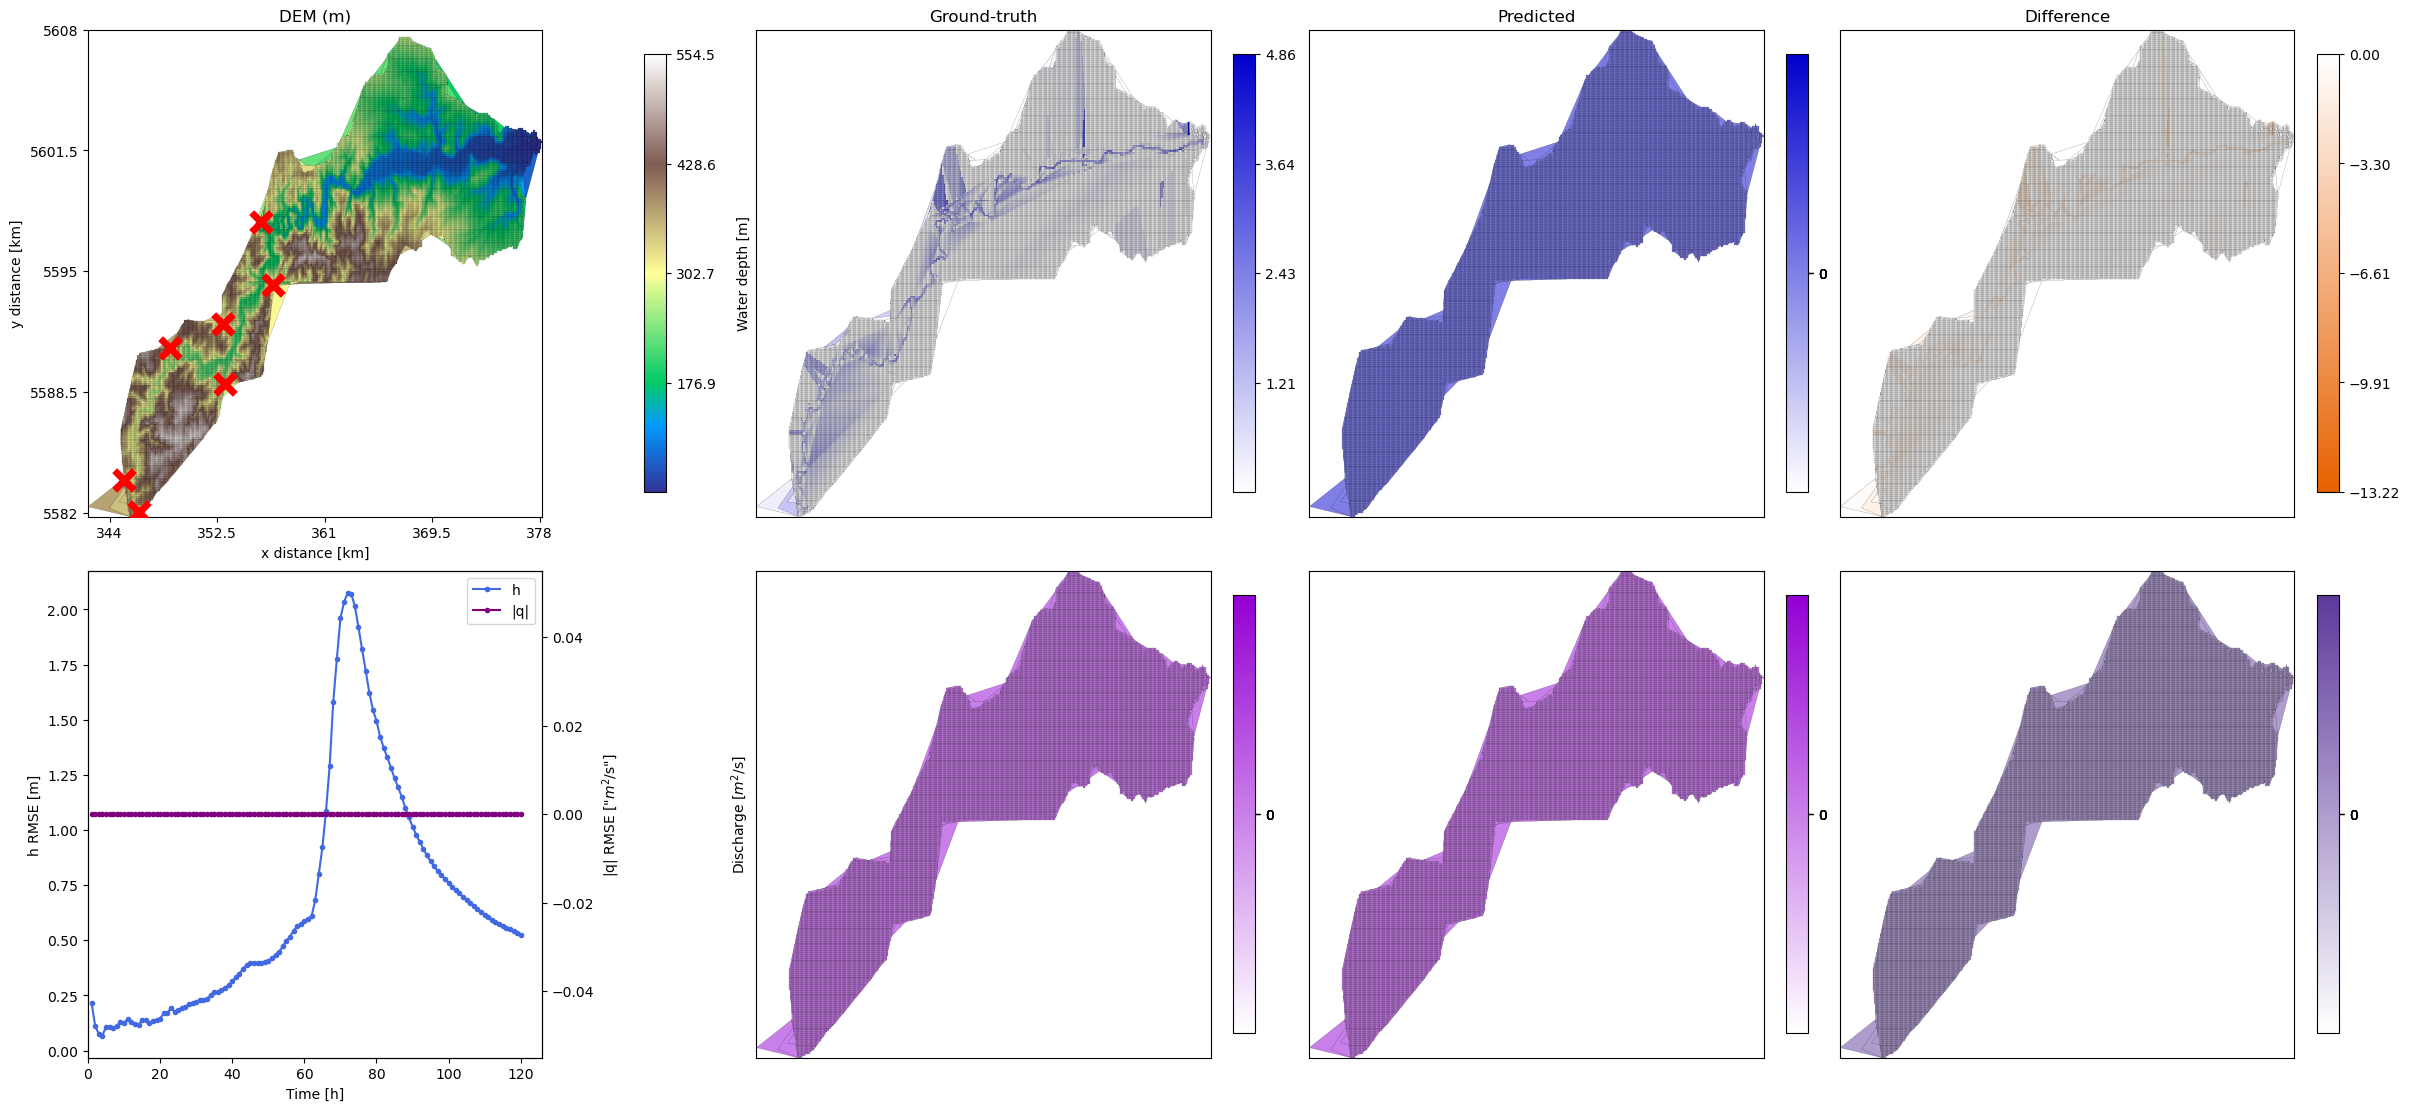

In [ ]:
# Snapshot at the last time step (DEM, SFINCS ground truth, prediction, difference)
fig = plot_rollout.explore_rollout(time_step=-1)
plt.show()

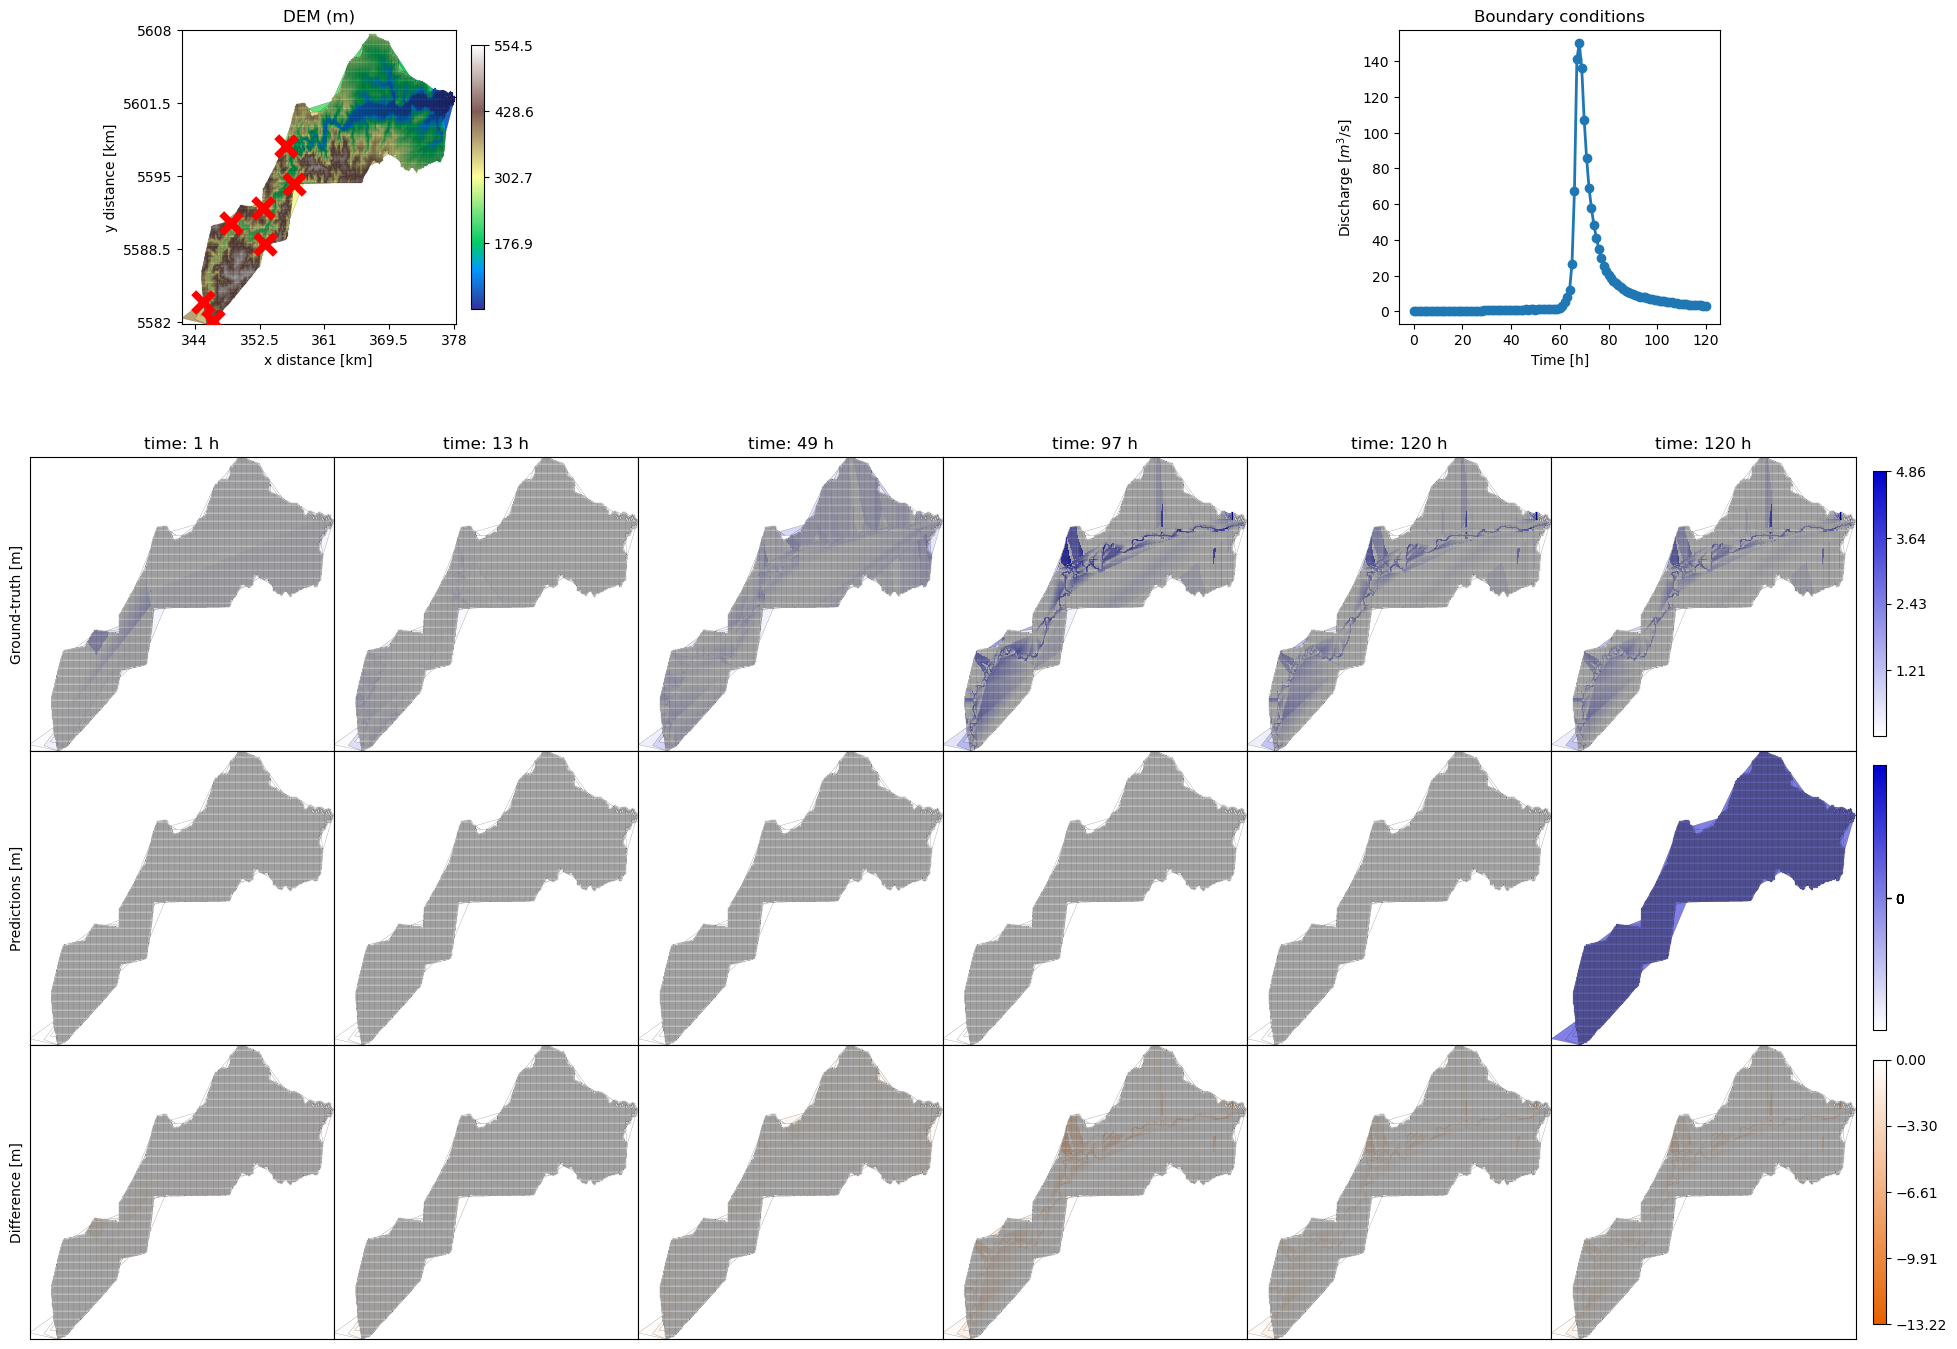

In [ ]:
# Water depth maps at selected hours (121 time steps @ 1 h)
plot_rollout.compare_h_rollout(plot_times=[0, 12, 48, 96, 119])
plt.show()

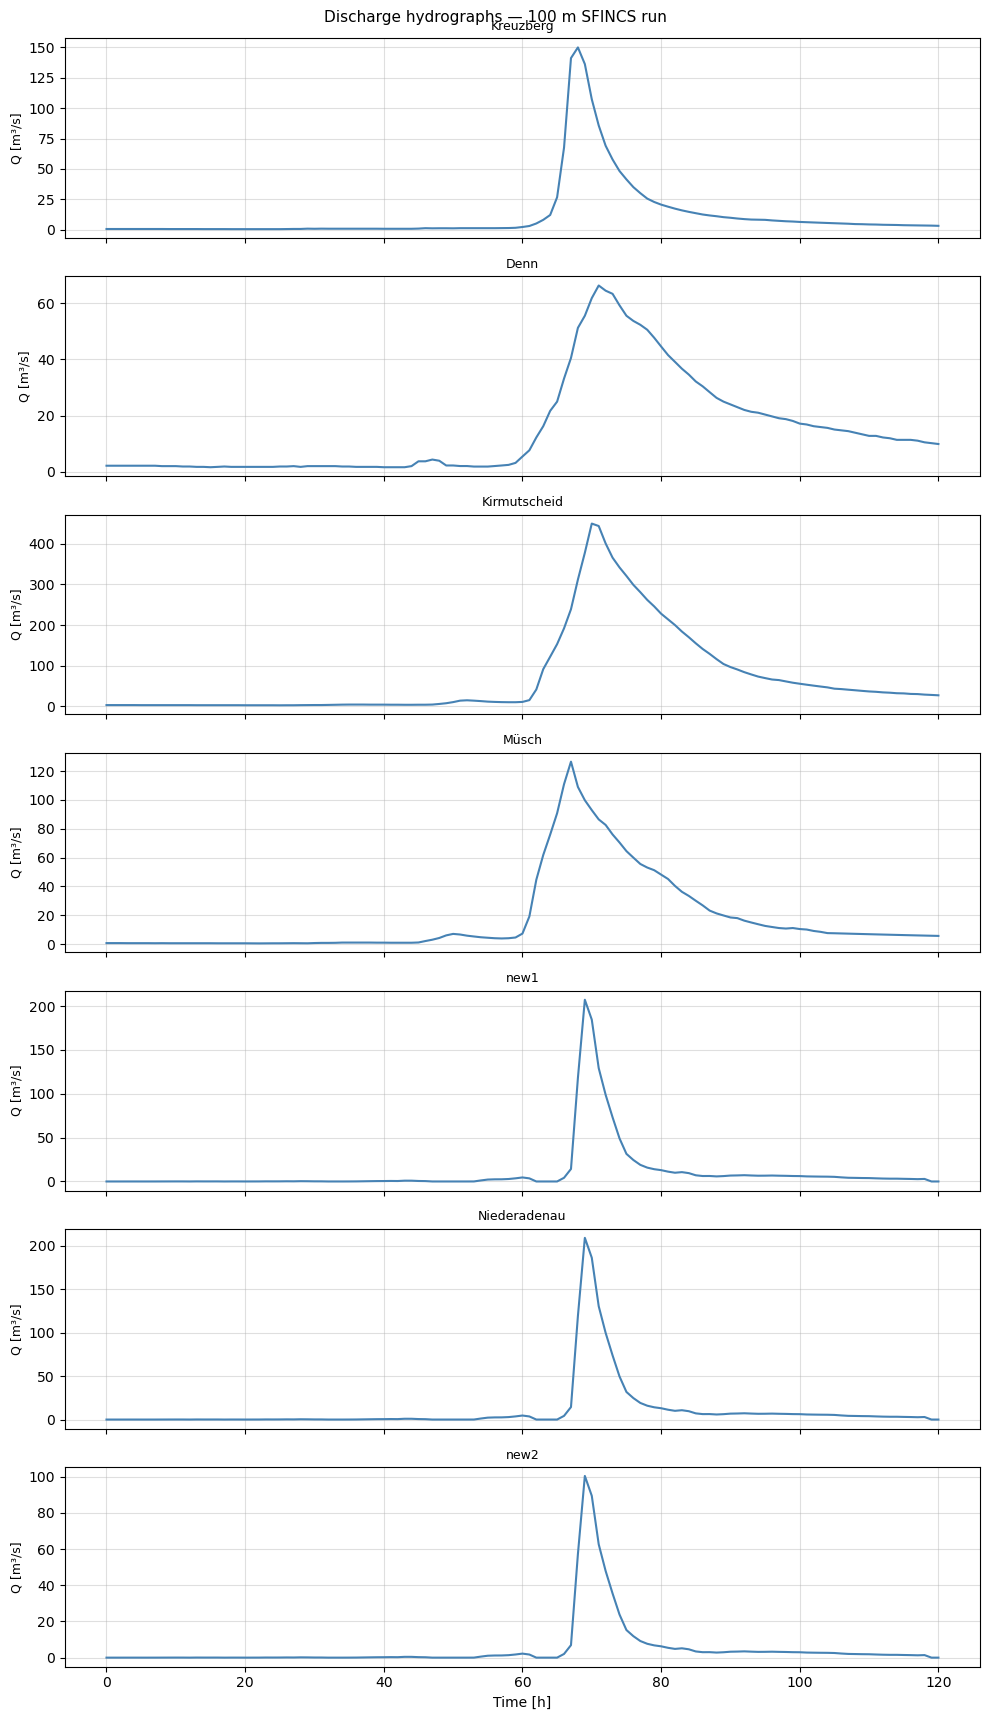

In [ ]:
# Source discharge hydrographs
src_names = ['Kreuzberg', 'Denn', 'Kirmutscheid', 'Müsch', 'new1', 'Niederadenau', 'new2']
data = test_dataset[0]
temporal_res = data.temporal_res   # minutes
bc = data.BC
n_bc = bc.shape[0]
t_hours = np.arange(bc.shape[1]) * temporal_res / 60.0

fig, axes = plt.subplots(n_bc, 1, figsize=(10, 2.5 * n_bc), sharex=True, facecolor='white')
for i, ax in enumerate(axes):
    q = bc[i].detach().cpu().numpy()
    q_vals = q[:, 1] if q.ndim == 2 else q   # channel 1 holds the hydrograph
    ax.plot(t_hours, q_vals, color='steelblue')
    ax.set_ylabel('Q [m³/s]', fontsize=9)
    ax.set_title(src_names[i] if i < len(src_names) else f'source {i}', fontsize=9)
    ax.grid(True, alpha=0.4)
axes[-1].set_xlabel('Time [h]')
fig.suptitle('Discharge hydrographs — 100 m SFINCS run', fontsize=11)
fig.tight_layout()
plt.show()

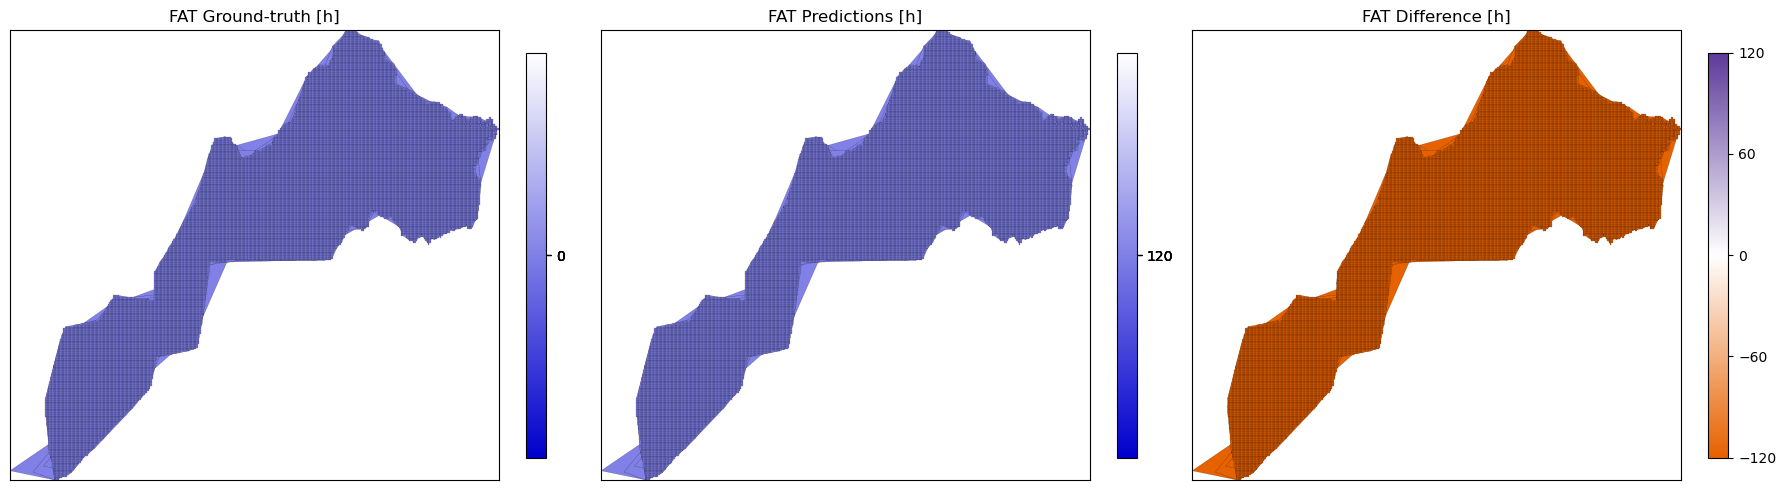

In [ ]:
# Flood arrival time comparison
plot_rollout.compare_FAT(water_threshold=0.05)
plt.show()

In [ ]:
# Quantitative metrics
rollout_loss = plot_rollout._get_rollout_loss(type_loss='MAE')
loss_mean = rollout_loss.mean(0)
print('rollout_loss shape:', rollout_loss.shape)
print(f'MAE WD:       {loss_mean[0].item():.4f} m' if loss_mean.dim() > 0 else f'MAE: {loss_mean.item():.4f}')
if loss_mean.dim() > 0 and loss_mean.shape[0] > 1:
    print(f'MAE V:        {loss_mean[1:].mean().item():.4f} m²/s')

csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
csi_03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()
print(f'CSI @ 0.05 m: {csi_005:.4f}')
print(f'CSI @ 0.30 m: {csi_03:.4f}')

rollout_loss shape: torch.Size([2])
MAE: 0.2171
CSI @ 0.05 m: 0.0000
CSI @ 0.30 m: 0.0000
